In [1]:
import numpy as np
import pandas as pd
import pickle

from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score
from scipy.stats import randint, uniform

from models import AvaliadorRandomForest
from utilitarios.visualizacao import DiagnosticoRegressao
from utilitarios.outros_utils import carregar_modelo

Carregando os dados

In [2]:
df_PCA_completo = pd.read_parquet(r'dados_brutos/fatores_pca_modelo_completo.parquet')
df_PCA = df_PCA_completo.loc[:,'TAXA_VIOLENCIA':]
df_unificado_filtrado = pd.read_parquet(r'Dados/base_de_dados_filtrada.parquet')
base_taxas_de_violencia_2010_2022= pd.read_parquet(r'Dados/taxas_de_violencia_2008_2022.parquet')
base_taxas_de_violencia_2010_2022_filtrada = pd.read_parquet(r'Dados/taxas_de_violencia_2008_2022_filtrada.parquet')

Setando os hiperparâmetros

In [ ]:
param_dist = {
    'n_estimators': randint(200, 500),
    'max_depth': randint(5, 30), # Reduzi profundidade máxima agressiva
    'max_features': [1, 2, 3, 4, 5],
    'min_samples_split': randint(5, 20),
    'min_samples_leaf': randint(2, 10), # Essencial para N pequeno
    'bootstrap': [True]
    }

avaliador = AvaliadorRandomForest(random_state=42)

In [7]:
y = df_PCA['TAXA_VIOLENCIA']
X = df_PCA.iloc[:,1:]

Treinamento: o algoritmo para encontrar o melhor random forest no intervalo de hiperparâmetros

In [ ]:
melhor_rf = avaliador.otimizar_hiperparametros(
    X, y, 
    param_distributions=param_dist, 
    n_iter=500, # Reduzido pois agora fazemos busca inteligente global
    cv_splits=5
    )

tamanhos, scores_treino, scores_teste = avaliador.gerar_curva_aprendizado(
    X, y,
    train_sizes=np.linspace(0.2, 1.0, 41) # De 20% a 100% da base
    )

avaliador.plotar_curva_aprendizado(tamanhos, scores_treino, scores_teste)

In [3]:
melhor_rf = carregar_modelo(model='melhor_rf.pkl')

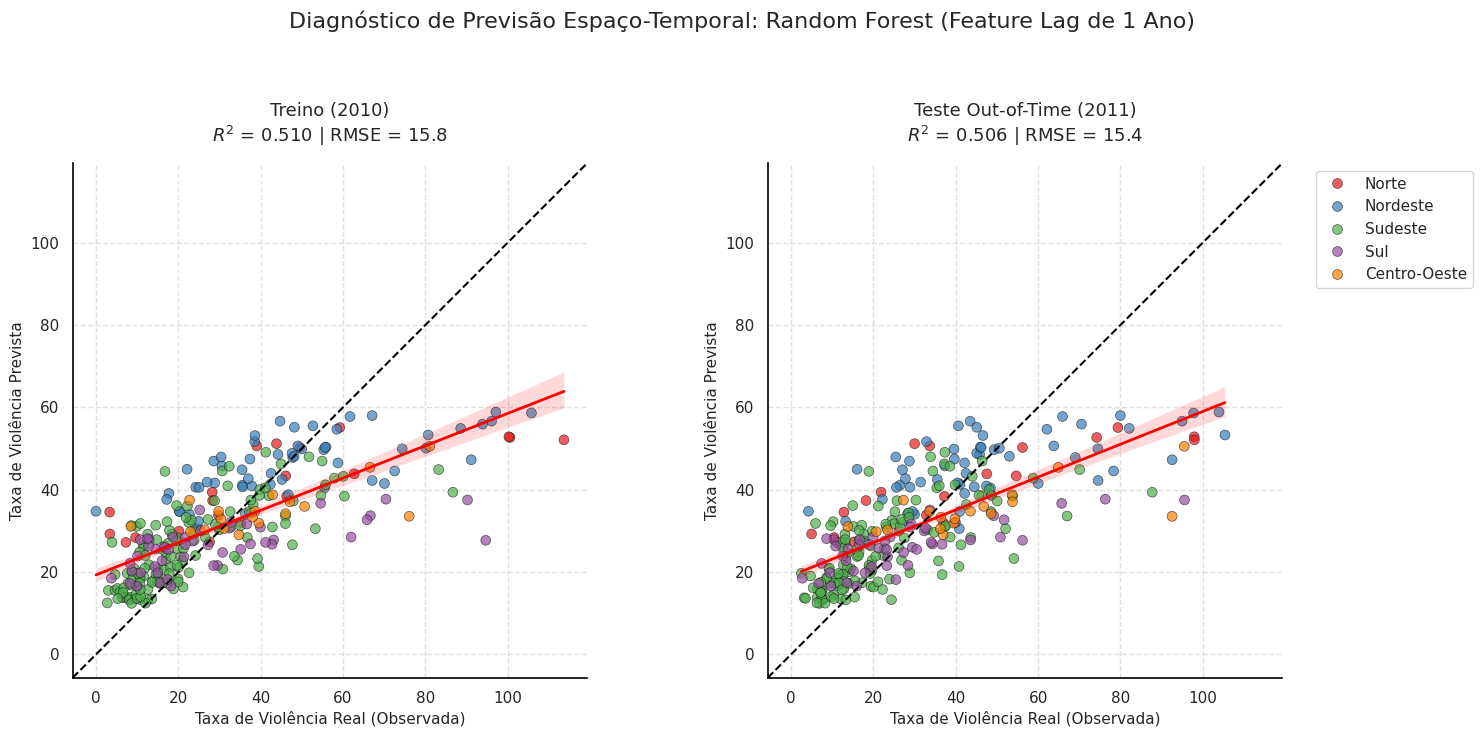

In [4]:
# 1. Base do Treino
X_train_2010 = df_PCA[['FATOR_POPULACAO', 'FATOR_EDUCACAO', 'FATOR_INFRAESTRUTURA', 'FATOR_POBREZA_DESIGUALDADE', 'FATOR_EMPREGO']]
# Extração crua para evitar desalinhamento no gráfico
y_train_verdadeiro = df_PCA['TAXA_VIOLENCIA'].to_numpy()

# Previsão da Random Forest sobre 2010
y_train_predito = melhor_rf.predict(X_train_2010)

# 2. Base do Teste (Feature Lag Temporal)
X_test_2011 = X_train_2010.copy() 
y_test_predito = y_train_predito.copy()

# A "Verdade" muda. Extraímos direto para numpy assumindo ordenação idêntica
y_test_verdadeiro = base_taxas_de_violencia_2010_2022_filtrada['TAXA_2011'].to_numpy()

# 3. O Filtro Geográfico
# Convertendo para array puro, destruímos os índices problemáticos
hue_treino = df_unificado_filtrado['REGIAO'].to_numpy()
hue_teste = df_unificado_filtrado['REGIAO'].to_numpy()

# 4. Instancia a classe de visualização e plota
diagnostico = DiagnosticoRegressao()

diagnostico.plotar_treino_teste_lado_a_lado(
    y_train_true=y_train_verdadeiro,
    y_train_pred=y_train_predito,
    y_test_true=y_test_verdadeiro,
    y_test_pred=y_test_predito,
    hue_train=hue_treino,
    hue_test=hue_teste,
    ano_treino="2010",
    ano_teste="2011",
    titulo_modelo="Random Forest (Feature Lag de 1 Ano)"
)

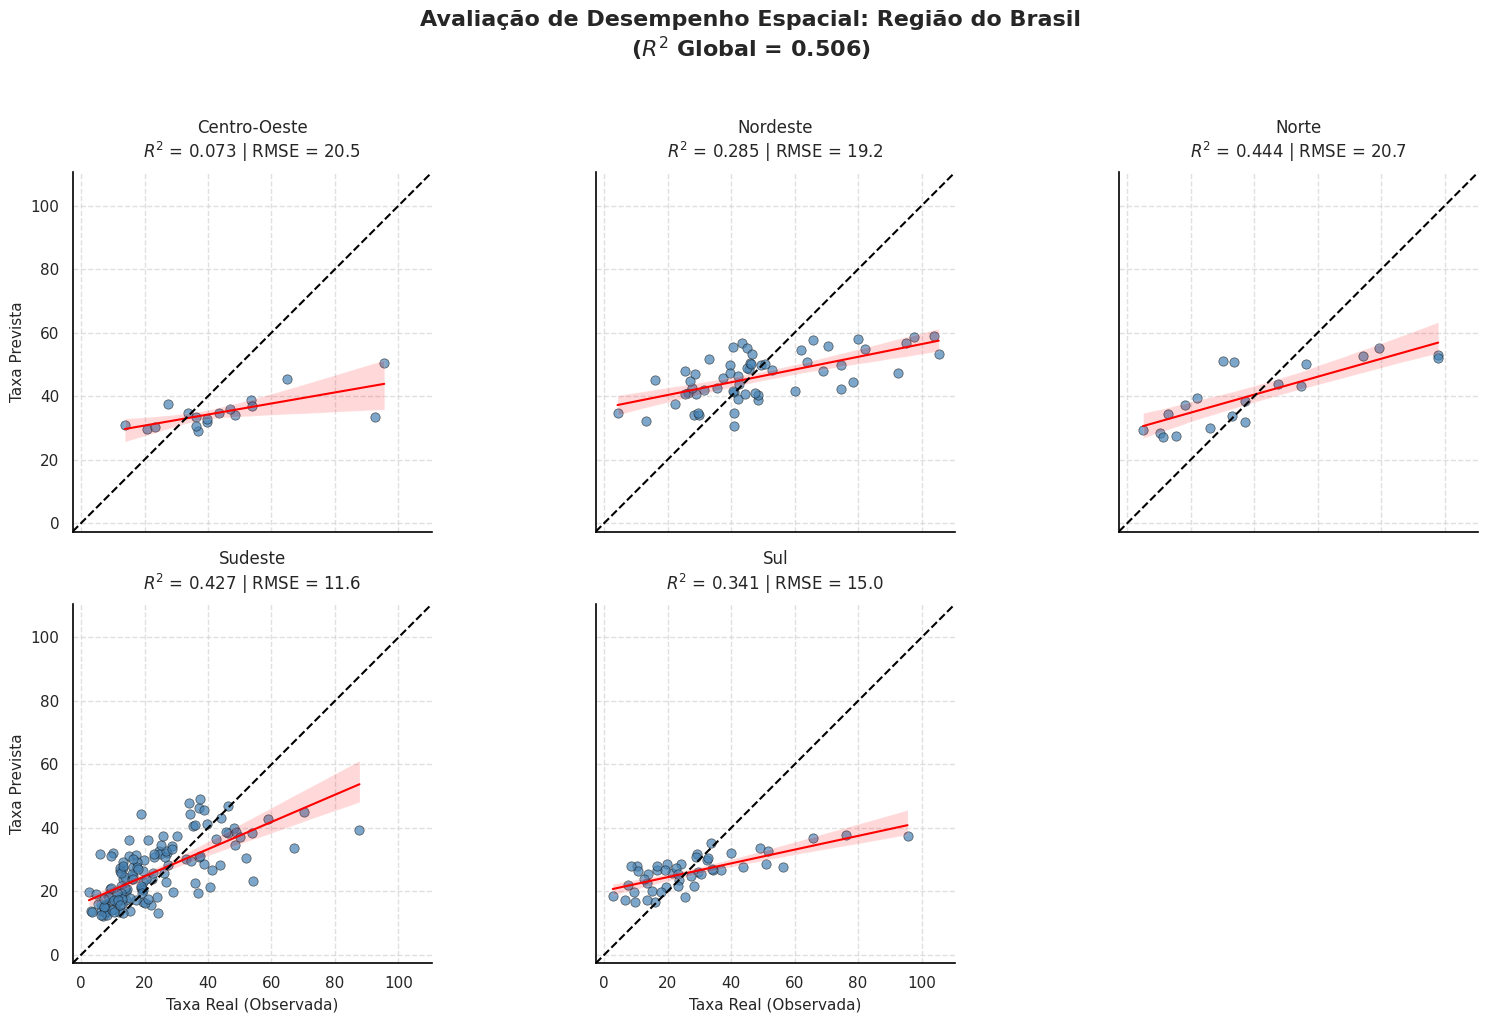

In [6]:
X_dados = df_PCA[[
    'FATOR_POPULACAO', 'FATOR_EDUCACAO', 'FATOR_INFRAESTRUTURA', 
    'FATOR_POBREZA_DESIGUALDADE', 'FATOR_EMPREGO'
    ]]

y_verdadeiro_numpy = base_taxas_de_violencia_2010_2022_filtrada['TAXA_2011'].to_numpy()

y_previsto_numpy = melhor_rf.predict(X_dados)

regioes_numpy = df_unificado_filtrado['REGIAO'].to_numpy()

diagnostico = DiagnosticoRegressao()

diagnostico.plotar_desempenho_por_estrato(
    y_true=y_verdadeiro_numpy,
    y_pred=y_previsto_numpy,
    estratos=regioes_numpy,
    nome_estrato="Região do Brasil",
    max_colunas=3 # O grid será 2 linhas x 3 colunas, com 1 quadrado vazio no final
)

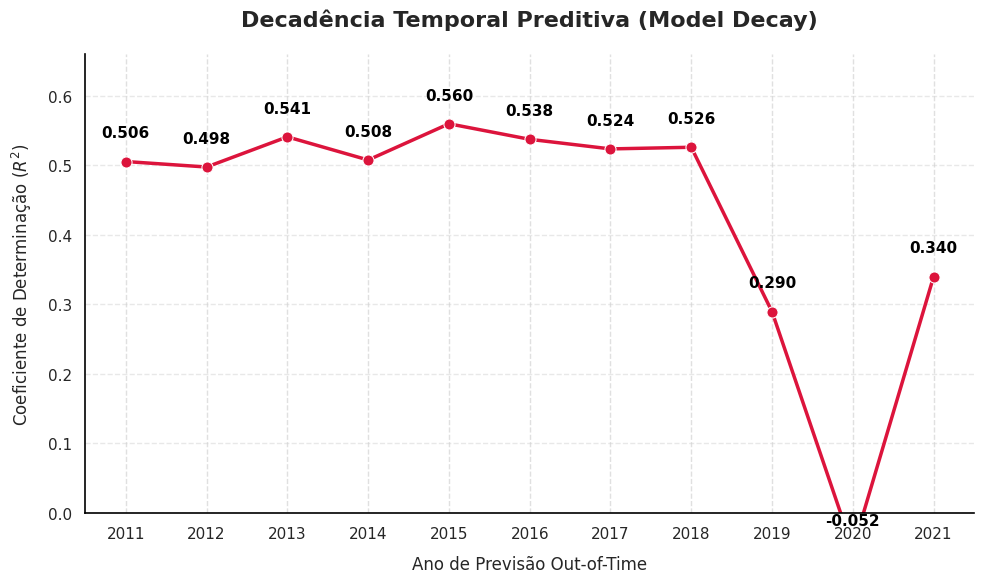

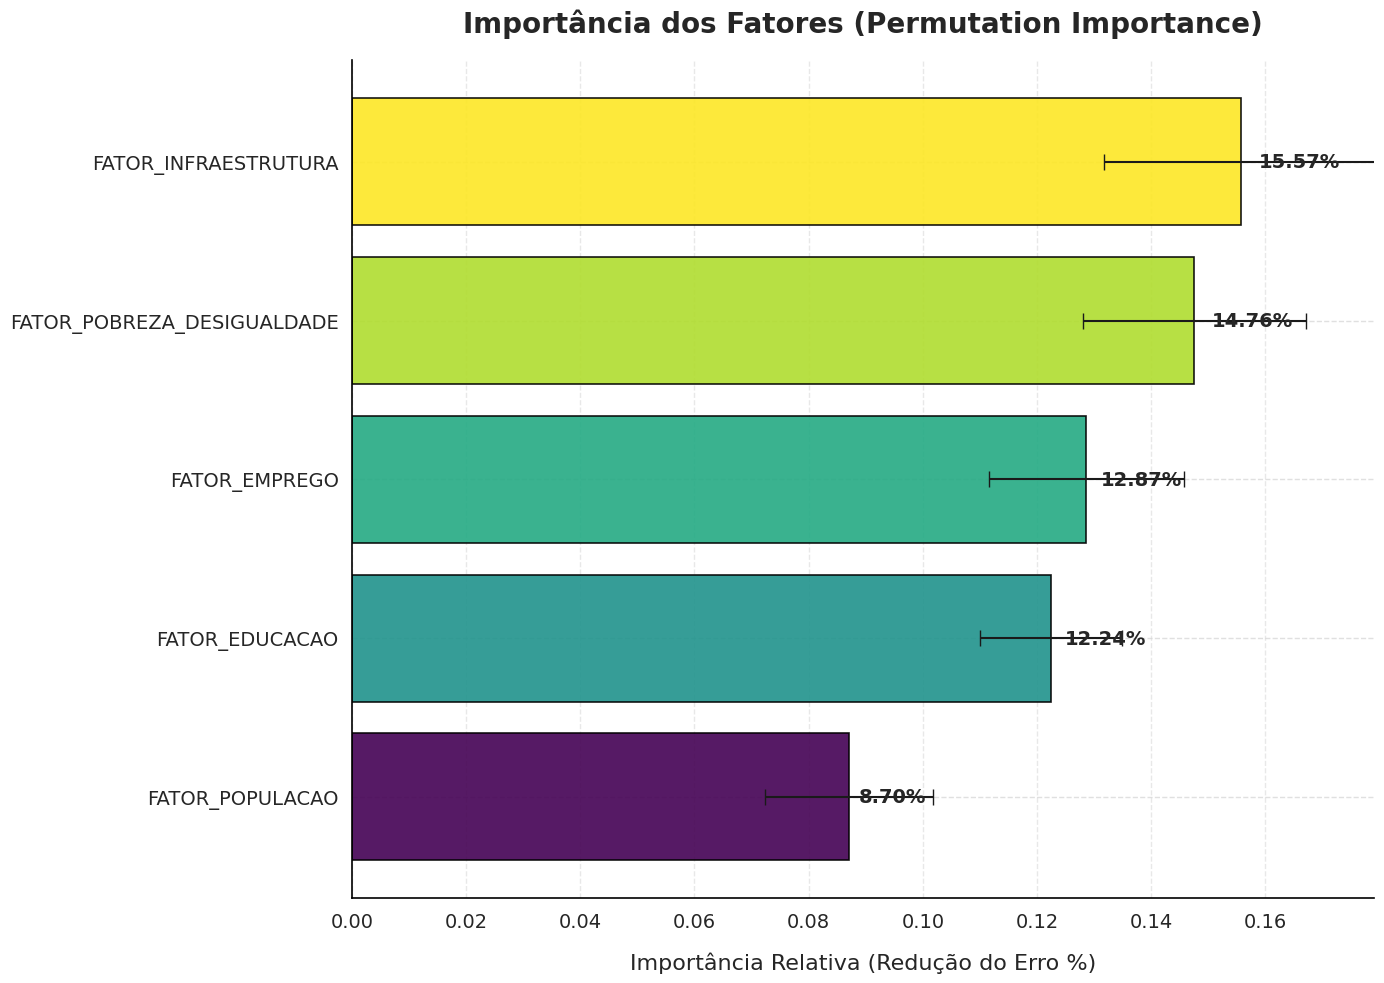

In [8]:
anos_extracao = []
r2_resultados = []

# MUDANÇA AQUI: Mantemos o DataFrame intacto (sem .to_numpy())
X_inferencia_df = df_PCA[['FATOR_POPULACAO', 'FATOR_EDUCACAO', 'FATOR_INFRAESTRUTURA', 'FATOR_POBREZA_DESIGUALDADE', 'FATOR_EMPREGO']]

# O Scikit-Learn enxerga o DF e para de emitir os warnings!
y_predito_estatico = melhor_rf.predict(X_inferencia_df)

colunas_temporais = [f'TAXA_{ano}' for ano in range(2011, 2022)]

for col in colunas_temporais:
    # Apenas o y_verdadeiro recebe strip de índice para garantir pareamento
    y_verdadeiro = base_taxas_de_violencia_2010_2022_filtrada[col].to_numpy()
    
    r2 = r2_score(y_verdadeiro, y_predito_estatico)
    anos_extracao.append(int(col.replace('TAXA_', '')))
    r2_resultados.append(r2)

anos_x_numpy = np.array(anos_extracao)
r2_y_numpy = np.array(r2_resultados)

# -------------------------------------------------------------------
# 2. PROCESSAMENTO DE DADOS: Permutation Importance
# -------------------------------------------------------------------
resultado_permutacao = permutation_importance(
    melhor_rf, 
    X_inferencia_df, # Passamos o DataFrame com rótulos!
    base_taxas_de_violencia_2010_2022_filtrada['TAXA_2011'].to_numpy(),
    n_repeats=10,
    random_state=42,
    n_jobs=-1,
    scoring='r2'
)

# Extraímos os rótulos dinamicamente das colunas do DataFrame
nomes_features_numpy = X_inferencia_df.columns.to_numpy()
importancias_medias = resultado_permutacao.importances_mean
importancias_std = resultado_permutacao.importances_std

# -------------------------------------------------------------------
# 3. RENDERIZAÇÃO
# -------------------------------------------------------------------
diagnostico = DiagnosticoRegressao()

diagnostico.plotar_decadencia_temporal(
    anos_x=anos_x_numpy,
    r2_y=r2_y_numpy,
    limite_inferior=0.0 
)

diagnostico.plotar_importancia_variaveis(
    nomes_features=nomes_features_numpy,
    importancias=importancias_medias,
    desvios_padrao=importancias_std,
    titulo='Importância dos Fatores (Permutation Importance)'
)